<a href="https://colab.research.google.com/github/CatalinaOrtegha/3rdChallenge-TelecomX/blob/main/Preparacion_de_los_datos_y_correlaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Preparación de los datos


##Dataset original

In [190]:
import pandas as pd

url='https://raw.githubusercontent.com/CatalinaOrtegha/2ndChallenge_TelecomX/refs/heads/main/df_limpio_telecomX_actualizacion.json'

df=pd.read_json(url)
df

,rotacion_cliente,genero_cliente,de_tercera_edad,tiene_pareja,tiene_dependientes,meses_contrato,tipo_contrato,metodo_pago,total_gastos_por_mes,total_gastos,cuentas_diarias
0,False,Mujeres,False,True,True,9,Anual,Cheque por correo,65.60,593.30,2.19
1,False,Hombres,False,False,False,9,Mensual,Cheque por correo,59.90,542.40,2.00
2,True,Hombres,False,False,False,4,Mensual,Cheque electrónico,73.90,280.85,2.46
3,True,Hombres,True,True,False,13,Mensual,Cheque electrónico,98.00,1237.85,3.27
4,True,Mujeres,True,True,False,3,Mensual,Cheque por correo,83.90,267.40,2.80
...,...,...,...,...,...,...,...,...,...,...,...
7262,False,Mujeres,False,False,False,13,Anual,Cheque por correo,55.15,742.90,1.84
7263,True,Hombres,False,True,False,22,Mensual,Cheque electrónico,85.10,1873.70,2.84
7264,False,Hombres,False,False,False,2,Mensual,Cheque por correo,50.30,92.75,1.68
7265,False,Hombres,False,True,True,67,Bienal,Cheque por correo,67.85,4627.65,2.26


In [191]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   rotacion_cliente      7032 non-null   bool   
 1   genero_cliente        7032 non-null   object 
 2   de_tercera_edad       7032 non-null   bool   
 3   tiene_pareja          7032 non-null   bool   
 4   tiene_dependientes    7032 non-null   bool   
 5   meses_contrato        7032 non-null   int64  
 6   tipo_contrato         7032 non-null   object 
 7   metodo_pago           7032 non-null   object 
 8   total_gastos_por_mes  7032 non-null   float64
 9   total_gastos          7032 non-null   float64
 10  cuentas_diarias       7032 non-null   float64
dtypes: bool(4), float64(3), int64(1), object(3)
memory usage: 467.0+ KB


In [219]:
import warnings
warnings.filterwarnings('ignore')

df['rotacion_cliente']= df['rotacion_cliente'].replace({'False': 0, 'True': 1}).astype(int)
df['de_tercera_edad']= df['de_tercera_edad'].replace({'False': 0, 'True': 1}).astype(int)
df['tiene_pareja']= df['tiene_pareja'].replace({'False': 0, 'True': 1}).astype(int)
df['tiene_dependientes']= df['tiene_dependientes'].replace({'False': 0, 'True': 1}).astype(int)
df['genero_cliente']= df['genero_cliente'].replace({'Hombres': 0, 'Mujeres': 1}).astype(int)

#Correlación y Selección de Variables

In [220]:
df_corr = df.copy()

In [221]:
df_corr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   rotacion_cliente      7032 non-null   int64  
 1   genero_cliente        7032 non-null   int64  
 2   de_tercera_edad       7032 non-null   int64  
 3   tiene_pareja          7032 non-null   int64  
 4   tiene_dependientes    7032 non-null   int64  
 5   meses_contrato        7032 non-null   int64  
 6   tipo_contrato         7032 non-null   object 
 7   metodo_pago           7032 non-null   object 
 8   total_gastos_por_mes  7032 non-null   float64
 9   total_gastos          7032 non-null   float64
 10  cuentas_diarias       7032 non-null   float64
dtypes: float64(3), int64(6), object(2)
memory usage: 659.2+ KB


In [229]:
categorico= df_corr.select_dtypes(include=['object']).columns

df_corr_encoded = pd.get_dummies(df_corr, columns=categorico, drop_first=True, dtype=int)

df_corr_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 14 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   rotacion_cliente                               7032 non-null   int64  
 1   genero_cliente                                 7032 non-null   int64  
 2   de_tercera_edad                                7032 non-null   int64  
 3   tiene_pareja                                   7032 non-null   int64  
 4   tiene_dependientes                             7032 non-null   int64  
 5   meses_contrato                                 7032 non-null   int64  
 6   total_gastos_por_mes                           7032 non-null   float64
 7   total_gastos                                   7032 non-null   float64
 8   cuentas_diarias                                7032 non-null   float64
 9   tipo_contrato_Bienal                           7032 non-n

## Matriz de correlación

In [196]:
import numpy as np

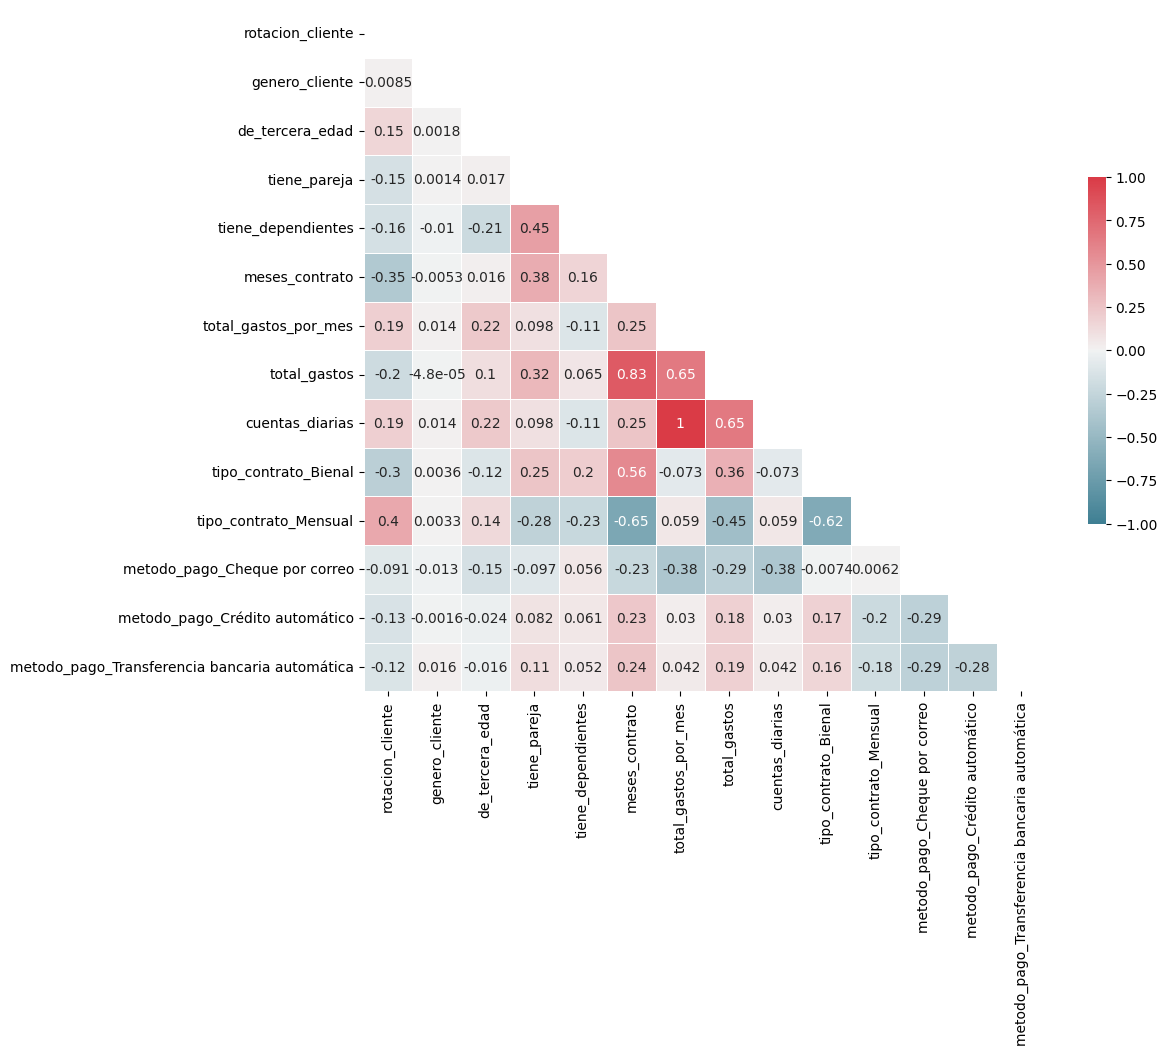

In [197]:
corr= df_corr_encoded.corr()

mascara = np.zeros_like(corr)
mascara[np.triu_indices_from(mascara)] = True

fig, ax = plt.subplots(figsize=(11,9))
cmap= sns.diverging_palette(220,10, as_cmap=True)
sns.heatmap(corr, mask=mascara, cmap=cmap, square=True, vmax=1, vmin=-1, center = 0, linewidths=.5, annot=True, cbar_kws={"shrink": .5})
plt.show()

In [198]:
import matplotlib.pyplot as plt
import seaborn as sns

##Boxplot: Relación: Tiempo de contrato × Cancelación

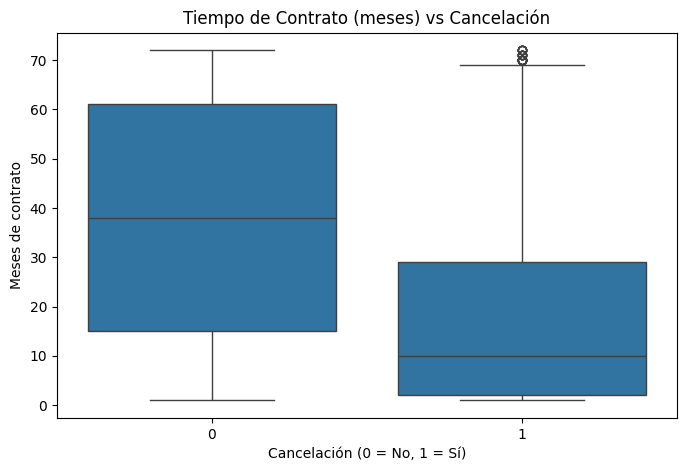

In [199]:
plt.figure(figsize=(8,5))
sns.boxplot(x='rotacion_cliente', y='meses_contrato', data=df)
plt.title("Tiempo de Contrato (meses) vs Cancelación")
plt.xlabel("Cancelación (0 = No, 1 = Sí)")
plt.ylabel("Meses de contrato")
plt.show()

##Scatter plot: Relación: Tiempo de contrato × Cancelación

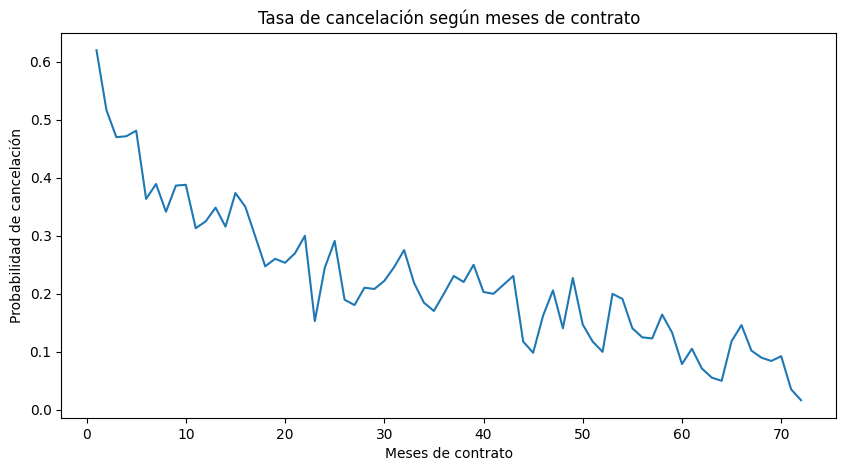

In [200]:
rotacion_mes = df.groupby('meses_contrato')['rotacion_cliente'].mean()

plt.figure(figsize=(10,5))
plt.plot(rotacion_mes)
plt.title("Tasa de cancelación según meses de contrato")
plt.xlabel("Meses de contrato")
plt.ylabel("Probabilidad de cancelación")
plt.show()

## Boxplot: Relación: Gasto total × Cancelación

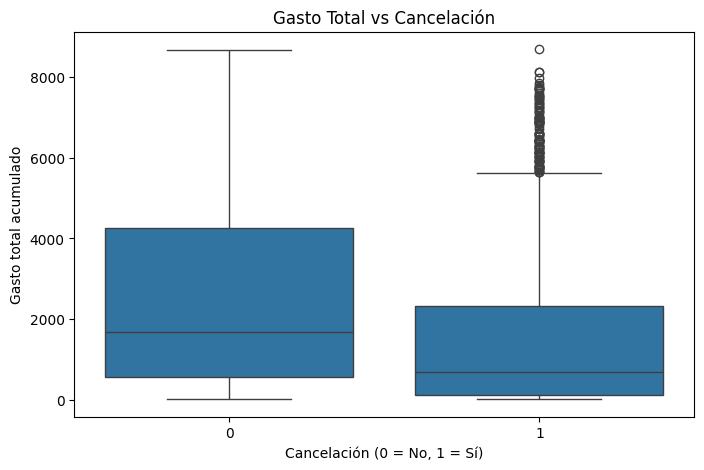

In [201]:
plt.figure(figsize=(8,5))
sns.boxplot(x='rotacion_cliente', y='total_gastos', data=df)
plt.title("Gasto Total vs Cancelación")
plt.xlabel("Cancelación (0 = No, 1 = Sí)")
plt.ylabel("Gasto total acumulado")
plt.show()

## Scatter de antigüedad + gasto

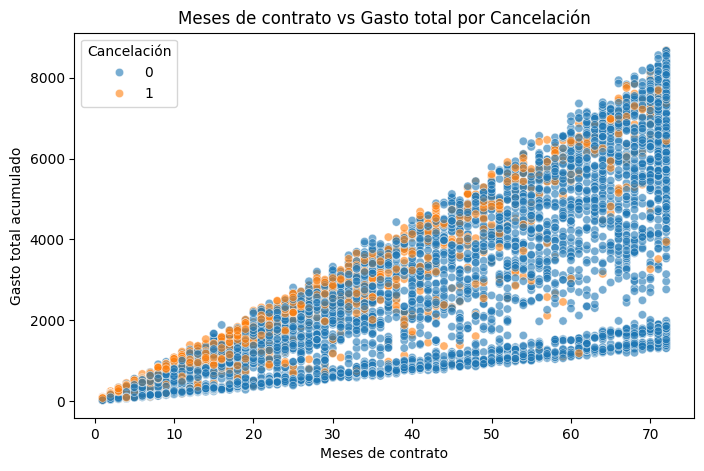

In [202]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='meses_contrato',
    y='total_gastos',
    hue='rotacion_cliente',
    alpha=0.6,
    data=df
)
plt.title("Meses de contrato vs Gasto total por Cancelación")
plt.xlabel("Meses de contrato")
plt.ylabel("Gasto total acumulado")
plt.legend(title='Cancelación')
plt.show()

##Separar X (features) Y y (target)

In [223]:
# 1️⃣ Separar primero

X = df_corr_encoded.drop("rotacion_cliente", axis=1)
y = df_corr_encoded["rotacion_cliente"]


## Verificación de la proporción de Cancelación (rotación cliente)

In [228]:
X

,genero_cliente,de_tercera_edad,tiene_pareja,tiene_dependientes,meses_contrato,total_gastos_por_mes,total_gastos,cuentas_diarias,tipo_contrato_Bienal,tipo_contrato_Mensual,metodo_pago_Cheque por correo,metodo_pago_Crédito automático,metodo_pago_Transferencia bancaria automática
0,1,0,1,1,9,65.60,593.30,2.19,0,0,1,0,0
1,0,0,0,0,9,59.90,542.40,2.00,0,1,1,0,0
2,0,0,0,0,4,73.90,280.85,2.46,0,1,0,0,0
3,0,1,1,0,13,98.00,1237.85,3.27,0,1,0,0,0
4,1,1,1,0,3,83.90,267.40,2.80,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,1,0,0,0,13,55.15,742.90,1.84,0,0,1,0,0
7263,0,0,1,0,22,85.10,1873.70,2.84,0,1,0,0,0
7264,0,0,0,0,2,50.30,92.75,1.68,0,1,1,0,0
7265,0,0,1,1,67,67.85,4627.65,2.26,1,0,1,0,0


In [224]:
y

,rotacion_cliente
0,0
1,0
2,1
3,1
4,1
...,...
7262,0
7263,1
7264,0
7265,0


In [225]:
y.value_counts(normalize=True).round(3)

,proportion
rotacion_cliente,
0,0.734
1,0.266


## Train / Test Split

In [206]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [230]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

numeric_features = X.select_dtypes(include=['int64','float64','bool']).columns

## Normalización (SCALER)

In [231]:
# 1. Definir el preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
    ]
)

In [232]:
# Pipeline completo
from imblearn.pipeline import Pipeline

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=1000))
])

# Entrenar
pipeline.fit(X_train, y_train)

# Predecir
y_pred = pipeline.predict(X_test)

## Balanceo (SMOTE)

In [233]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [234]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=1000))
])

# 6. Entrenar SOLO con entrenamiento
pipeline.fit(X_train, y_train)

# 7. Predecir
y_pred = pipeline.predict(X_test)

In [235]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[728 305]
 [ 75 299]]
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.50      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.74      1407



In [236]:
from sklearn.metrics import roc_auc_score

y_proba = pipeline.predict_proba(X_test)[:,1]
roc_auc_score(y_test, y_proba)

np.float64(0.8303717949381636)